# Machine Learning. An introduction

## 1. What is Machine Learning?

For complex fluid systems in Engineering, experiments or computational simulations (CFD) can easily take hours, days or weeks. In some cases, when many combinations
of operating conditions or geometrical configurations have to be tested (for instance, for optimization) it is no viable the use of a massive
number of heavy and slow simulations, and a [**surrogate model**](https://en.wikipedia.org/wiki/Surrogate_model), also know as **meta-model**, can be used.
We have done something similar in the section about rheology, when curve fitting was used to model the complex behaviour of rheological fluid.

[**Machine Learning**](https://en.wikipedia.org/wiki/Machine_learning) is a field of Artificial Intelligence where statistical algorithms use **data** to
"teach" a computer how to perform some tasks related to the system that supplied the data.  The model created
with ML is intended to be _fast_ (much faster than CFD) and _accurate_ enough (but not as accurate as CFD...).

This algorithms are classified in

- **Supervised learning**, where data are "labeled" by a "teacher" or "supervisor" according to some outcome. The intention is to create a process able to map. This si used for **classification** (discrete data)
and **regression** (continuous data).
    any the incomes to the outcomes.
- **Unsupervised learning**, where there are no labels. Typical example is **clustering**
- **Reinforcement learning**, a "hybrid" approach where an agent (some kind of "robot") learns how to perform tasks according to some kind of *reward" for successful actions.

In this session we are going to use a regressor (supervised learning) in order to create a surrogate model that
avoids to perform expensive experiments or numerical computations.

We are going to use the python package [scikit-learn](https://scikit-learn.org/stable/index.html). Other free
python libraries extensively used for Machine Learning are [pyTorch](https://pytorch.org/) or [tensorFlow](https://www.tensorflow.org/) by Google.

But first let's we do some easier examples of supervised machine learning

## 2.- Data exploration

Before we perform machine learning, we do some exercises of data exploration and manipulation with the
python package [seaborn](https://seaborn.pydata.org/) based on matplotlib and especifically designed for this purpose.

Seaborn provides access to a bunch of [datasets](https://github.com/mwaskom/seaborn-data/tree/master) to play with. For instance, we can fetch the data for almost 400 cars produced around the world between 1970 and 1982. We get
a pandas dataframe with the data

In [2]:
import seaborn as sns
from pandas.io.sas.sas_xport import XportReader

df = sns.load_dataset('mpg')

`mpg` stands for "miles per gallon". The conversion to liters per 100 km, more usual in Europe, is
$$
1 \,\text{mpg} = 0.425 \,\text{km/l}
$$

In [3]:
df.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin,name
0,18.0,8,307.0,130.0,3504,12.0,70,usa,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,usa,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,usa,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,usa,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,usa,ford torino


We can see how the consumption of fuel as decreased with the year prodcution

<Axes: xlabel='model_year', ylabel='mpg'>

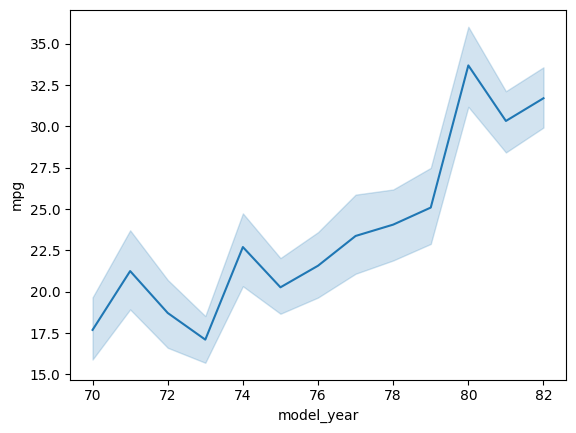

In [6]:
sns.lineplot(data=df, x='model_year', y='mpg')

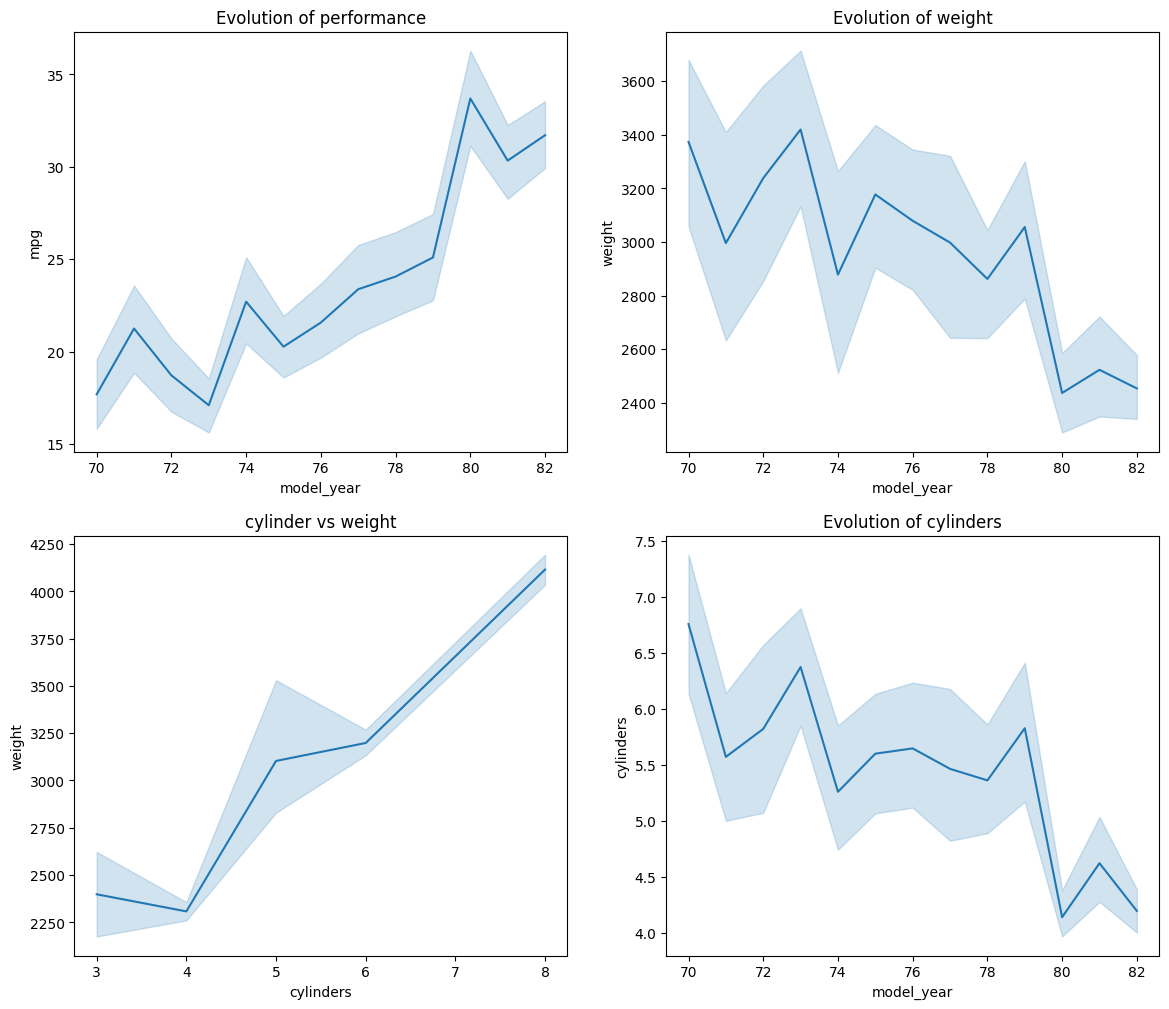

In [7]:
import matplotlib.pyplot as plt
fig = plt.figure(figsize=(14,12))
ax = fig.add_subplot(221)
ax = sns.lineplot(x="model_year", y="mpg", data=df)
ax.set_title('Evolution of performance')
ax1 = fig.add_subplot(222)
ax1 = sns.lineplot(x="model_year", y="weight", data=df)
ax1.set_title('Evolution of weight')
ax2 = fig.add_subplot(223)
ax2 = sns.lineplot(x="cylinders", y="weight", data=df)
ax2.set_title('cylinder vs weight')
ax3 = fig.add_subplot(224)
ax3 = sns.lineplot(x="model_year", y="cylinders", data=df)
ax3.set_title('Evolution of cylinders')
plt.show()

This graph show the evolution of th performance as a function of the origin of the car

<Axes: xlabel='model_year', ylabel='mpg'>

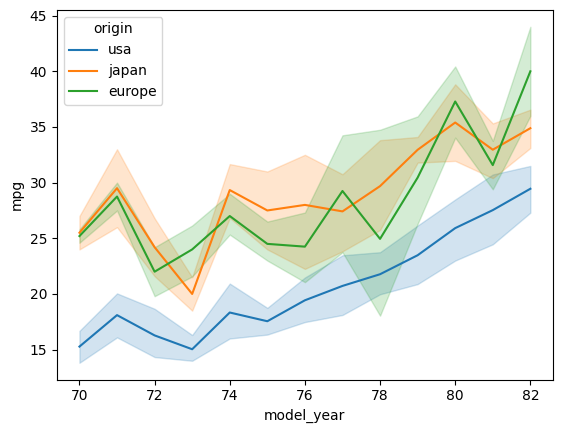

In [8]:
sns.lineplot(x="model_year", y="mpg",hue='origin',data=df)

We check if there is some kind of correlation between performance and weight.

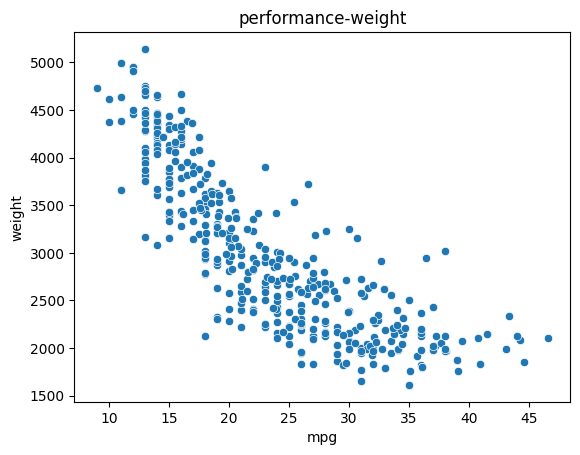

In [10]:
sns.scatterplot(x="mpg", y="weight", data=df).set_title('performance-weight');

Even better, we can perform a linear regression

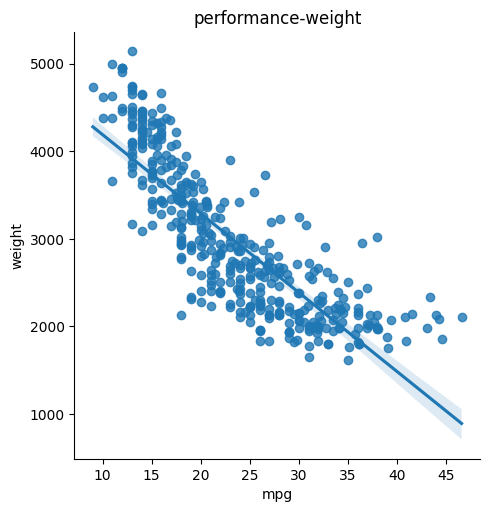

In [12]:
sns.lmplot(x="mpg", y="weight", data=df).set(title='performance-weight');

Or a second order regression

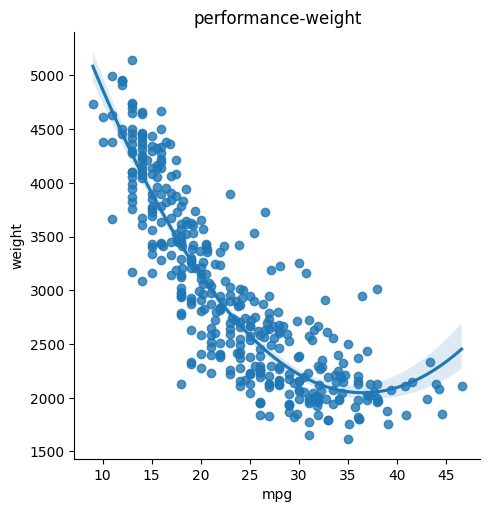

In [13]:
sns.lmplot(x="mpg", y="weight", data=df, order=2).set(title='performance-weight');


And, even better, grouped according to origin

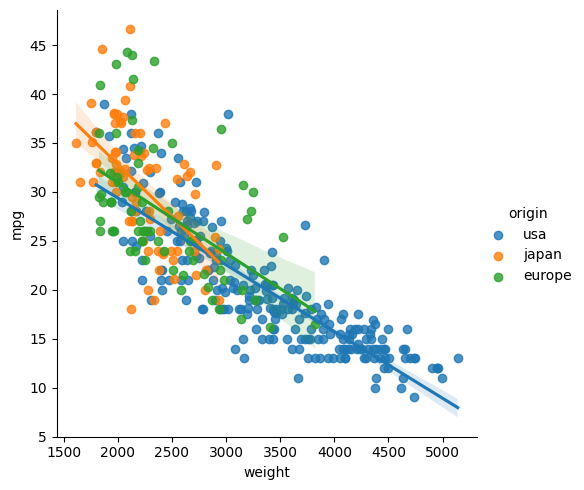

In [14]:
sns.lmplot(x="weight", y="mpg", hue='origin',data=df)

Also, we can relate number of cylinders and acceleration with bar plots.

<Axes: xlabel='cylinders', ylabel='acceleration'>

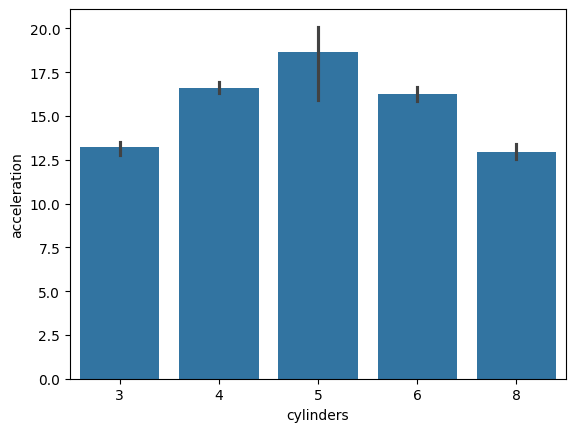

In [15]:
sns.barplot(x="cylinders", y="acceleration", data=df)

and introducing even the origin

<Axes: xlabel='cylinders', ylabel='acceleration'>

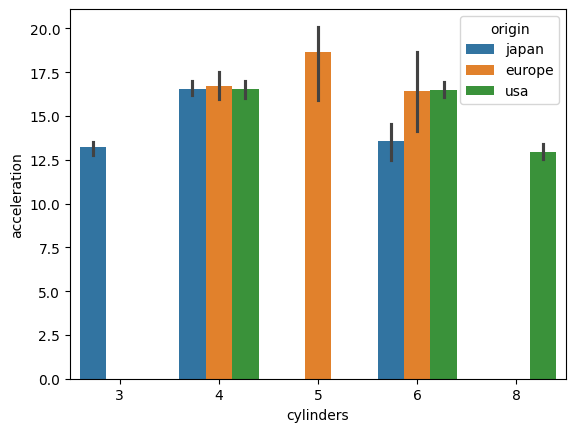

In [16]:
sns.barplot(x="cylinders", y="acceleration", hue='origin', data=df)

You can easily draw conclusions from these plots...

It is quite easy also to plot an histogram distribution of the weight of the cars

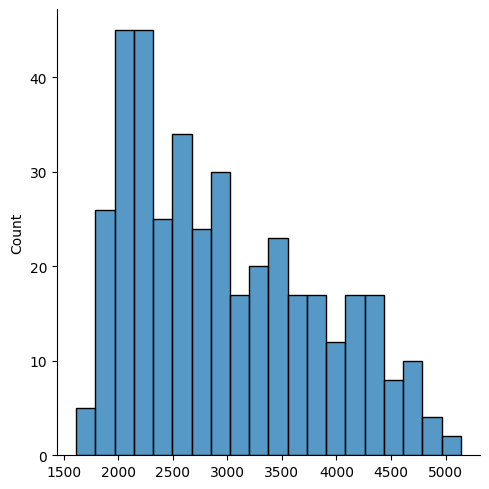

In [18]:
sns.displot(df["weight"].values,bins=20)

The mean and the median can be marked and plotted.

<Figure size 1000x600 with 0 Axes>

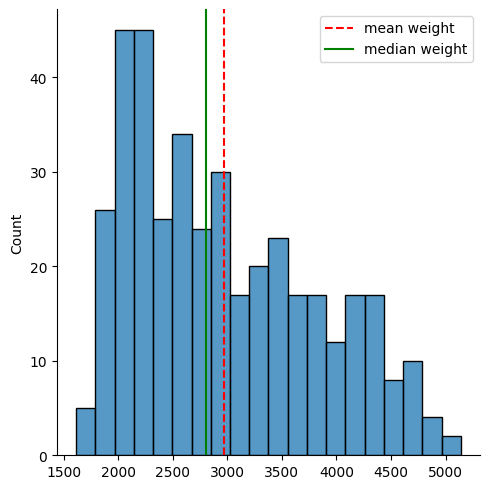

In [21]:
media_weight = df['weight'].mean()
mediana_weight = df['weight'].median()

fig = plt.figure(figsize=(10,6))
ax=sns.displot(df["weight"].values,bins=20)
plt.axvline(media_weight, color="r", linestyle="--", label='mean weight')
plt.axvline(mediana_weight, color="g", linestyle="-", label='median weight')
plt.legend()

Joint distribution plots can also be shown

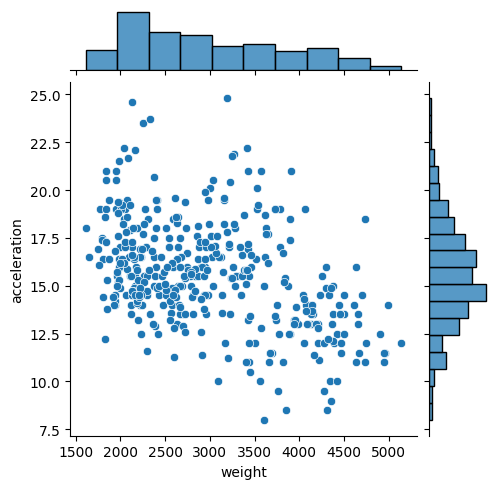

In [24]:
sns.jointplot(x='weight',y='acceleration',data=df,height=5)

And, finally, we can have a global representation of all the variables

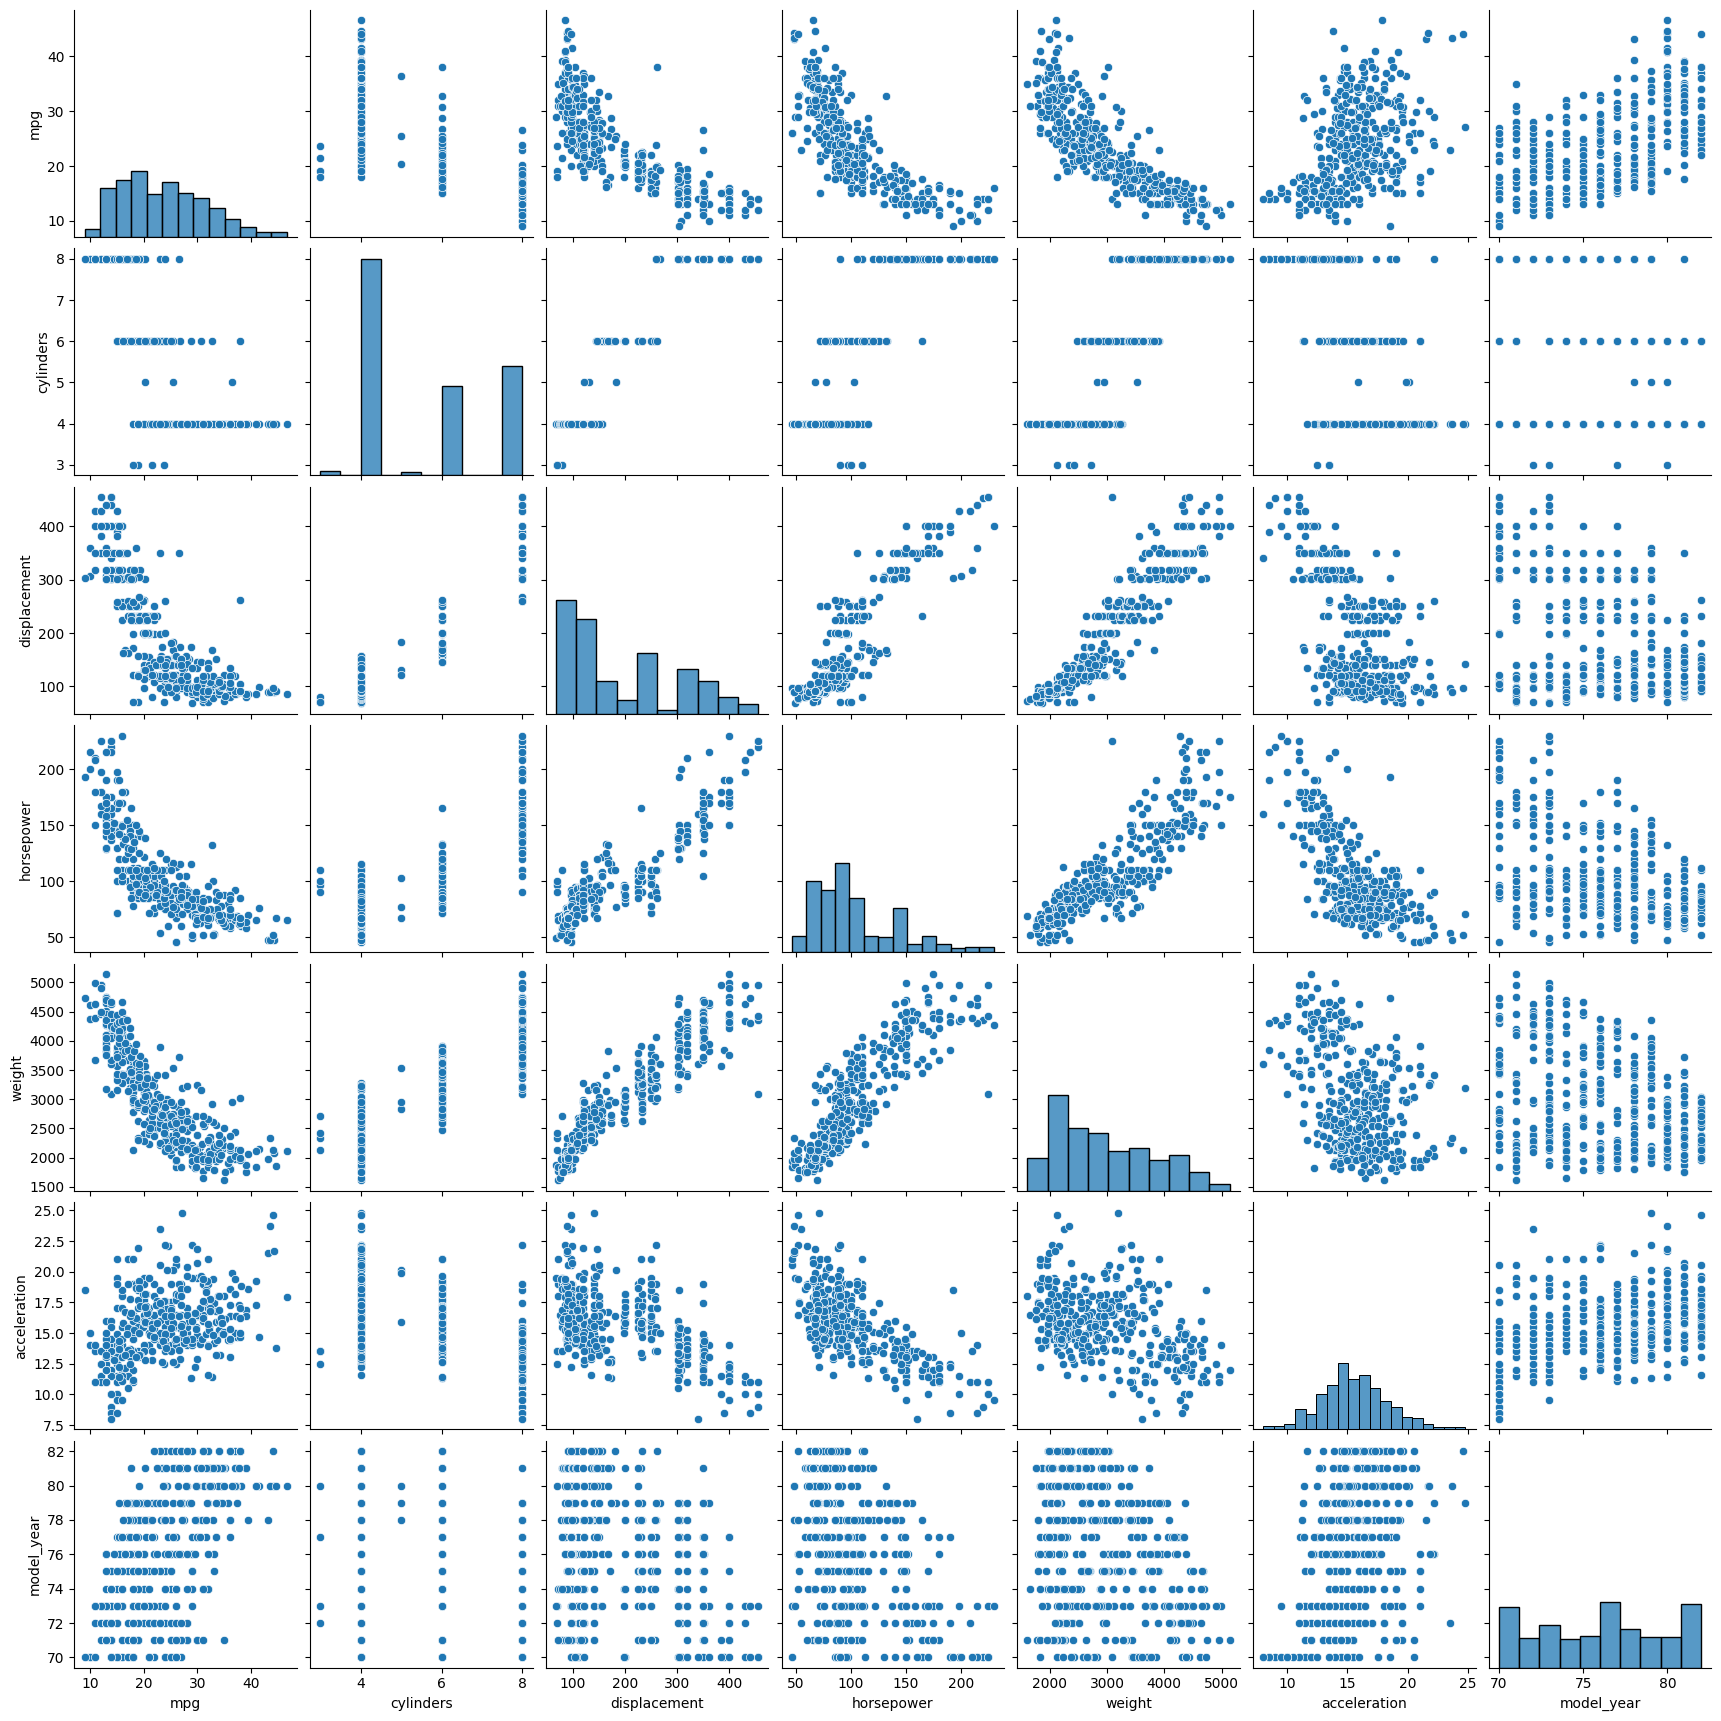

In [25]:
sns.pairplot(df)

Better with colors according to origin

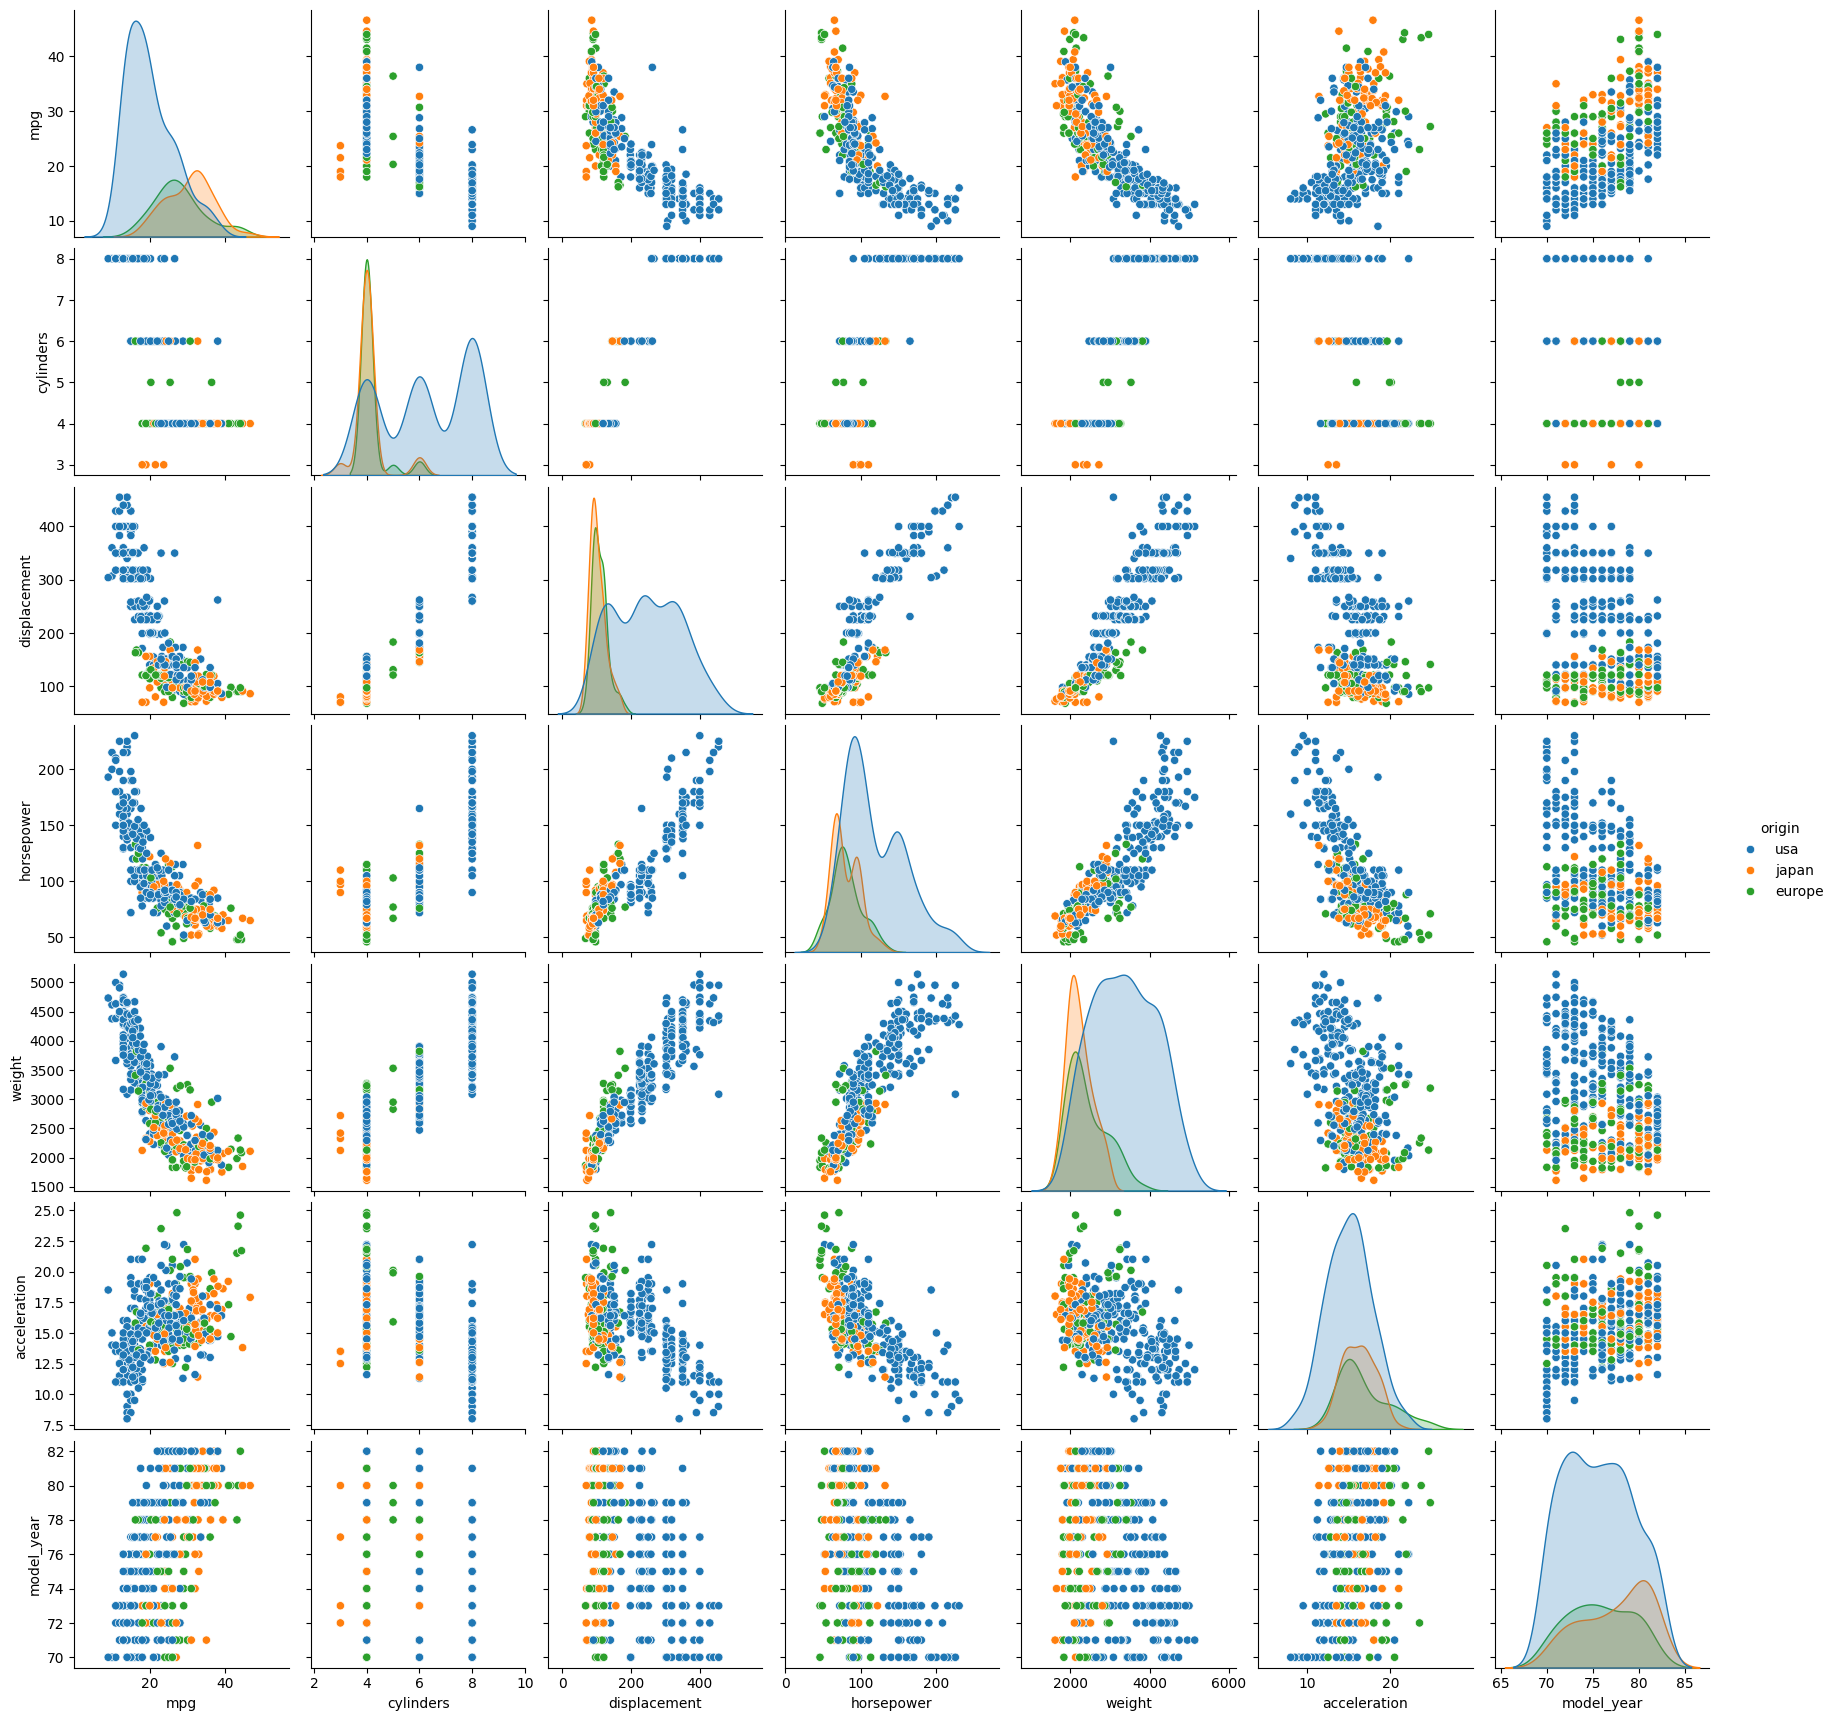

In [28]:
sns.pairplot(df, hue='origin')

**Exercise:**

Play with the `penguins` dataset. Note that you will find some `NaN` elements...

## 3.- Dimensionality reduction. PCA

In many datasets (cars, fluid devices, ...) we can have a lot of variables (also called in this context **features**). It is impossible for
us to visualize more than 3 variables. Imagine to visualize a data set with 20 or more features!

**Principal Components Analysis (PCA)** is a unsupervised ML technique that extracts the most important component from a high-dimensional dataset
into a few important dimensions.

We consider for this exercise the `iris` dataset, composed of 151 samples of flowers of 3 species.

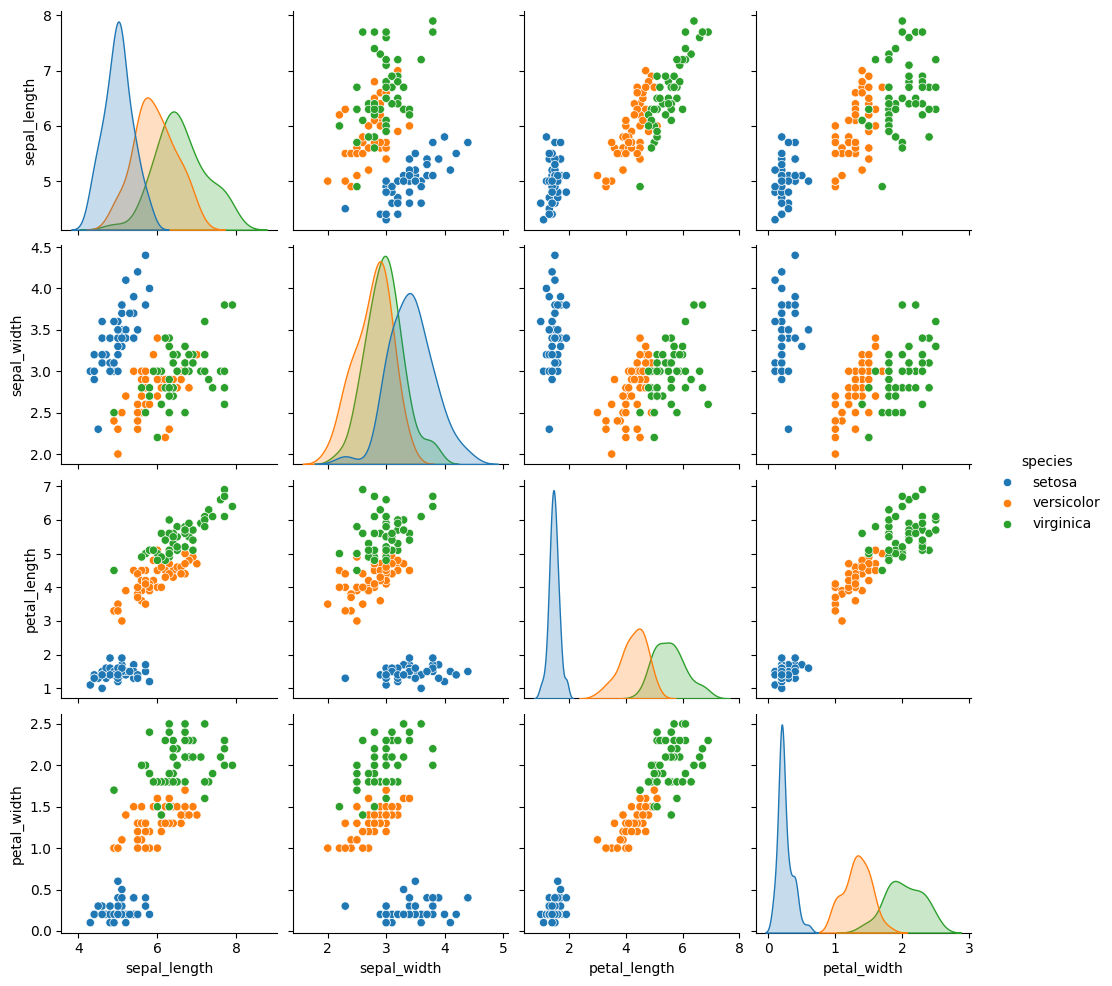

In [29]:
iris = sns.load_dataset("iris")
sns.pairplot(iris, hue="species")

We have 4 features, that makes difficult to visualize the data. We can reduce these 4 features to only 2 components, that will make
the visualization and exploration easier.

First we have to scale all teh features, since PCA is based on the importance of absolute numerical values. In this case it is not taht important,
but in the case of the cars, for instance, we cannot compare mpg (about 10-20) with weight (some thousands...).

In [30]:
X = iris[['sepal_length','sepal_width','petal_length','petal_width']] # features
y = iris['species'] # class labels - This identifies this ML as supervised. Someone had to define this label

In [32]:
# We scale the features
from sklearn.preprocessing import StandardScaler
XS = StandardScaler().fit_transform(X)

Now we can perform the PCA on the features. We do that with 4 components, just to see the importance of all teh variables.

In [33]:
from sklearn import decomposition
pca = decomposition.PCA(n_components=4).fit(XS)

 `fit` is only the model. We have to transform the original data, by projecting it in the PCA space.

In [35]:
Xproj = pca.transform(XS)

In [39]:
Xproj.shape

(150, 4)

This matrix makes the transformations between the rea features and the PC's.

In [41]:
pca.components_

array([[ 0.52106591, -0.26934744,  0.5804131 ,  0.56485654],
       [ 0.37741762,  0.92329566,  0.02449161,  0.06694199],
       [ 0.71956635, -0.24438178, -0.14212637, -0.63427274],
       [-0.26128628,  0.12350962,  0.80144925, -0.52359713]])

We can see how the PC's are contributing to the system information

In [42]:
pca.explained_variance_ratio_.cumsum()

array([0.72962445, 0.95813207, 0.99482129, 1.        ])

Teh two first PC's, namely PC1 and PC2, contain almost 96% of the total information provided by the 4 features. We can work  with
this two new variables, losing only about 4% of the information

<Axes: xlabel='PCA1', ylabel='PCA2'>

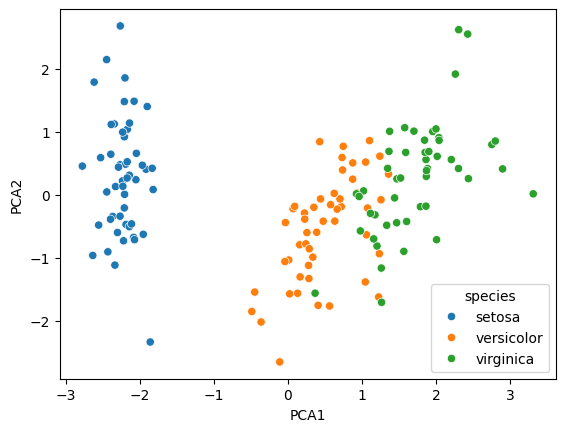

In [45]:
import pandas as pd
dfpca = pd.DataFrame(Xproj[:,0:2],columns=['PCA1', 'PCA2'])
sns.scatterplot(data=dfpca, x='PCA1', y='PCA2', hue=y)


**Exercise:**

Apply PCA to the `mpg` dataset. How many PC's do we need to get 90% of the information?